# 03 · Decoding: greedy vs beam search

The second ablation axis, using `checkpoints/transformer_xe.pt`. Beam search keeps the k best partial captions at each step and ranks finished ones by `log P(caption) / length^α`, so α = 0 favours short captions and α = 1 averages per word.

Both settings are tuned on **val only**; test numbers are in notebook 04.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from pycocoevalcap.cider.cider import Cider
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import SOS_IDX, ImageFeatureDataset, load_processed, reference_captions, split_images, tokenize
from src.decoding import beam_search, generate_captions
from src.models import load_checkpoint
from src.utils import caption_scores

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
RESULTS = ROOT / "results" / "transformer"
device = torch.device("cuda")

features, images, vocab = load_processed(ROOT / "data" / "processed")
train_images, val_images = split_images(images, "train"), split_images(images, "val")
val_refs = reference_captions(val_images)
# Same batch size as validation during training: bf16 kernels differ slightly across batch sizes, which can flip
# near-tied greedy choices, and the check below requires an exact reproduction of the saved score.
val_image_loader = DataLoader(ImageFeatureDataset(features, val_images), batch_size=256)

model, ckpt = load_checkpoint(ROOT / "checkpoints" / "transformer_xe.pt", device)
viz.note(f"Loaded <code>transformer_xe.pt</code>: epoch {ckpt['epoch']}, dropout {ckpt['model_config']['dropout']}, "
         f"val CIDEr at save time {ckpt['val_scores']['CIDEr']:.3f}")

## 1. Greedy decoding
Should reproduce the val CIDEr recorded when the checkpoint was saved.

In [2]:
start = time.time()
greedy = generate_captions(model, val_image_loader, vocab, device, beam_size=1)
greedy_seconds = time.time() - start
scores = caption_scores(val_refs, greedy)
display(viz.table(pd.DataFrame([{"decoding": "greedy", **scores, "images / sec": len(greedy) / greedy_seconds}]),
                  caption="Val set (1,014 images)", formats={"images / sec": "{:.0f}"}))
assert abs(scores["CIDEr"] - ckpt["val_scores"]["CIDEr"]) < 1e-6, "greedy decode does not reproduce the checkpoint score"

decoding,BLEU-1,BLEU-2,BLEU-3,BLEU-4,CIDEr,images / sec
greedy,0.656,0.470,0.330,0.231,0.476,463


## 2. Beam search sweep (val)
Beam size k ∈ {1, 2, 3, 5, 7, 10} × length penalty α ∈ {0, 0.5, 1}.

In [3]:
BEAM_SIZES = [1, 2, 3, 5, 7, 10]
LENGTH_PENALTIES = [0.0, 0.5, 1.0]

rows, outputs = [], {}
for alpha in LENGTH_PENALTIES:
    for k in BEAM_SIZES:
        start = time.time()
        caps = greedy if k == 1 else generate_captions(model, val_image_loader, vocab, device, beam_size=k, length_penalty=alpha)
        seconds = time.time() - start if k > 1 else greedy_seconds
        outputs[(k, alpha)] = caps
        rows.append({"beam size": k, "α": alpha, **caption_scores(val_refs, caps),
                     "avg words": np.mean([len(c.split()) for c in caps.values()]), "seconds": seconds})
sweep = pd.DataFrame(rows)
sweep.to_csv(RESULTS / "decoding_sweep_val.csv", index=False)

cider_grid = sweep.pivot(index="beam size", columns="α", values="CIDEr")
cider_grid.columns = [f"α = {a:g}" for a in cider_grid.columns]
display(cider_grid.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None)
        .highlight_max(axis=None, props=viz.HIGHLIGHT)
        .set_caption("Val CIDEr by beam size (rows) and length penalty α (columns)")
        .set_table_styles([{"selector": "caption", "props": "caption-side: top; text-align: left; font-weight: 700; padding-bottom: 6px"},
                           {"selector": "td, th", "props": "padding: 4px 14px; text-align: right"}]))

,α = 0,α = 0.5,α = 1
beam size,,,
1,0.476,0.476,0.476
2,0.483,0.492,0.492
3,0.491,0.498,0.504
5,0.474,0.484,0.497
7,0.464,0.492,0.509
10,0.452,0.486,0.509


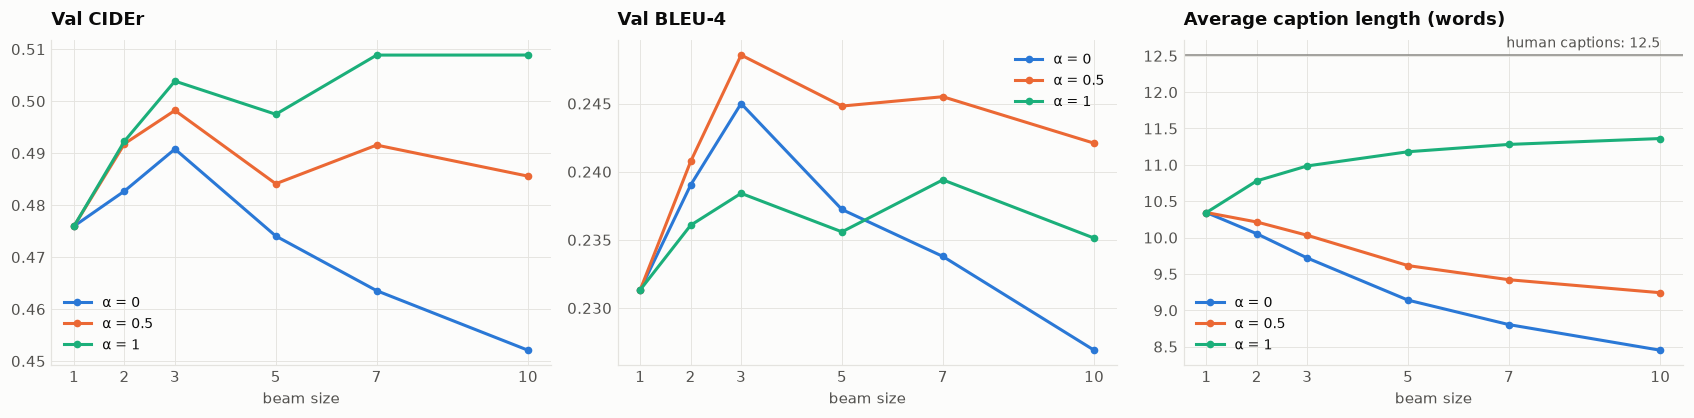

In [4]:
human_len = np.mean([len(tokenize(c)) for img in val_images for c in img["captions"]])
fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.9))
for alpha in LENGTH_PENALTIES:
    sub = sweep[sweep["α"] == alpha]
    for ax, col in zip(axes, ["CIDEr", "BLEU-4", "avg words"]):
        ax.plot(sub["beam size"], sub[col], marker="o", ms=4, label=f"α = {alpha:g}")
for ax, title in zip(axes, ["Val CIDEr", "Val BLEU-4", "Average caption length (words)"]):
    ax.set(title=title, xlabel="beam size", xticks=BEAM_SIZES)
    ax.legend()
axes[2].axhline(human_len, color=viz.INK_3, lw=1)
axes[2].annotate(f"human captions: {human_len:.1f}", (BEAM_SIZES[-1], human_len), textcoords="offset points",
                 xytext=(0, 5), ha="right", color=viz.INK_2, fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "decoding_sweep_val.png")
plt.show()

In [5]:
best = sweep.loc[sweep.CIDEr.idxmax()]
BEST = {"beam_size": int(best["beam size"]), "length_penalty": float(best["α"])}
(RESULTS / "best_decoding.json").write_text(json.dumps(BEST, indent=2))
beam = outputs[(BEST["beam_size"], BEST["length_penalty"])]
g = sweep.iloc[0]
display(viz.table(pd.DataFrame([
    {"decoding": "greedy", "BLEU-4": g["BLEU-4"], "CIDEr": g.CIDEr, "avg words": g["avg words"], "seconds": g.seconds},
    {"decoding": f"beam k={BEST['beam_size']}, α={BEST['length_penalty']:g}", "BLEU-4": best["BLEU-4"], "CIDEr": best.CIDEr,
     "avg words": best["avg words"], "seconds": best.seconds},
]), maximize=["BLEU-4", "CIDEr"], caption="Best beam setting on val vs greedy", formats={"seconds": "{:.1f}", "avg words": "{:.1f}"}))
viz.note(f"Beam search (k={BEST['beam_size']}, α={BEST['length_penalty']:g}) improves val CIDEr by "
         f"<b>{(best.CIDEr - g.CIDEr) / g.CIDEr:+.1%}</b> and BLEU-4 by <b>{(best['BLEU-4'] - g['BLEU-4']) / g['BLEU-4']:+.1%}</b>")
for name, caps in [("greedy", greedy), ("beam", beam)]:
    (RESULTS / f"val_captions_{name}.json").write_text(json.dumps(caps, indent=2))

decoding,BLEU-4,CIDEr,avg words,seconds
greedy,0.231,0.476,10.3,2.2
"beam k=10, α=1",0.235,0.509,11.4,75.0


## 3. How beam search changes the captions
**repeats a phrase** = some word pair occurs twice; **distinct captions** = different captions ÷ images; **copied from train** = caption appears word for word in training. The human row uses one random reference per image (Flickr30k lists captions roughly longest first).

In [6]:
train_caption_set = {" ".join(tokenize(c)) for img in train_images for c in img["captions"]}
rng = np.random.default_rng(0)
human = {img["filename"]: " ".join(tokenize(rng.choice(img["captions"]))) for img in val_images}


def repeats_phrase(text):
    words = text.split()
    bigrams = list(zip(words, words[1:]))
    return len(bigrams) != len(set(bigrams))


def caption_stats(caps):
    texts = list(caps.values())
    return {
        "avg words": np.mean([len(t.split()) for t in texts]),
        "distinct captions": len(set(texts)) / len(texts),
        "repeats a phrase": np.mean([repeats_phrase(t) for t in texts]),
        "copied from train": np.mean([t in train_caption_set for t in texts]),
        "vocabulary used": len({w for t in texts for w in t.split()}),
    }


stats = pd.DataFrame([
    {"captions": "greedy", **caption_stats(greedy)},
    {"captions": f"beam (k={BEST['beam_size']}, α={BEST['length_penalty']:g})", **caption_stats(beam)},
    {"captions": "human (1 random reference per image)", **caption_stats(human)},
])
display(viz.table(stats, caption="Caption statistics (val)", percent=["repeats a phrase", "distinct captions", "copied from train"],
                  formats={"avg words": "{:.1f}"}))

captions,avg words,distinct captions,repeats a phrase,copied from train,vocabulary used
greedy,10.3,92.6%,7.5%,8.7%,569
"beam (k=10, α=1)",11.4,90.5%,9.5%,6.7%,577
human (1 random reference per image),12.6,100.0%,6.3%,0.7%,"2,021"


## 4. Where beam search helps and hurts
The 3 val images that gained the most from beam search, and the 3 that lost the most.

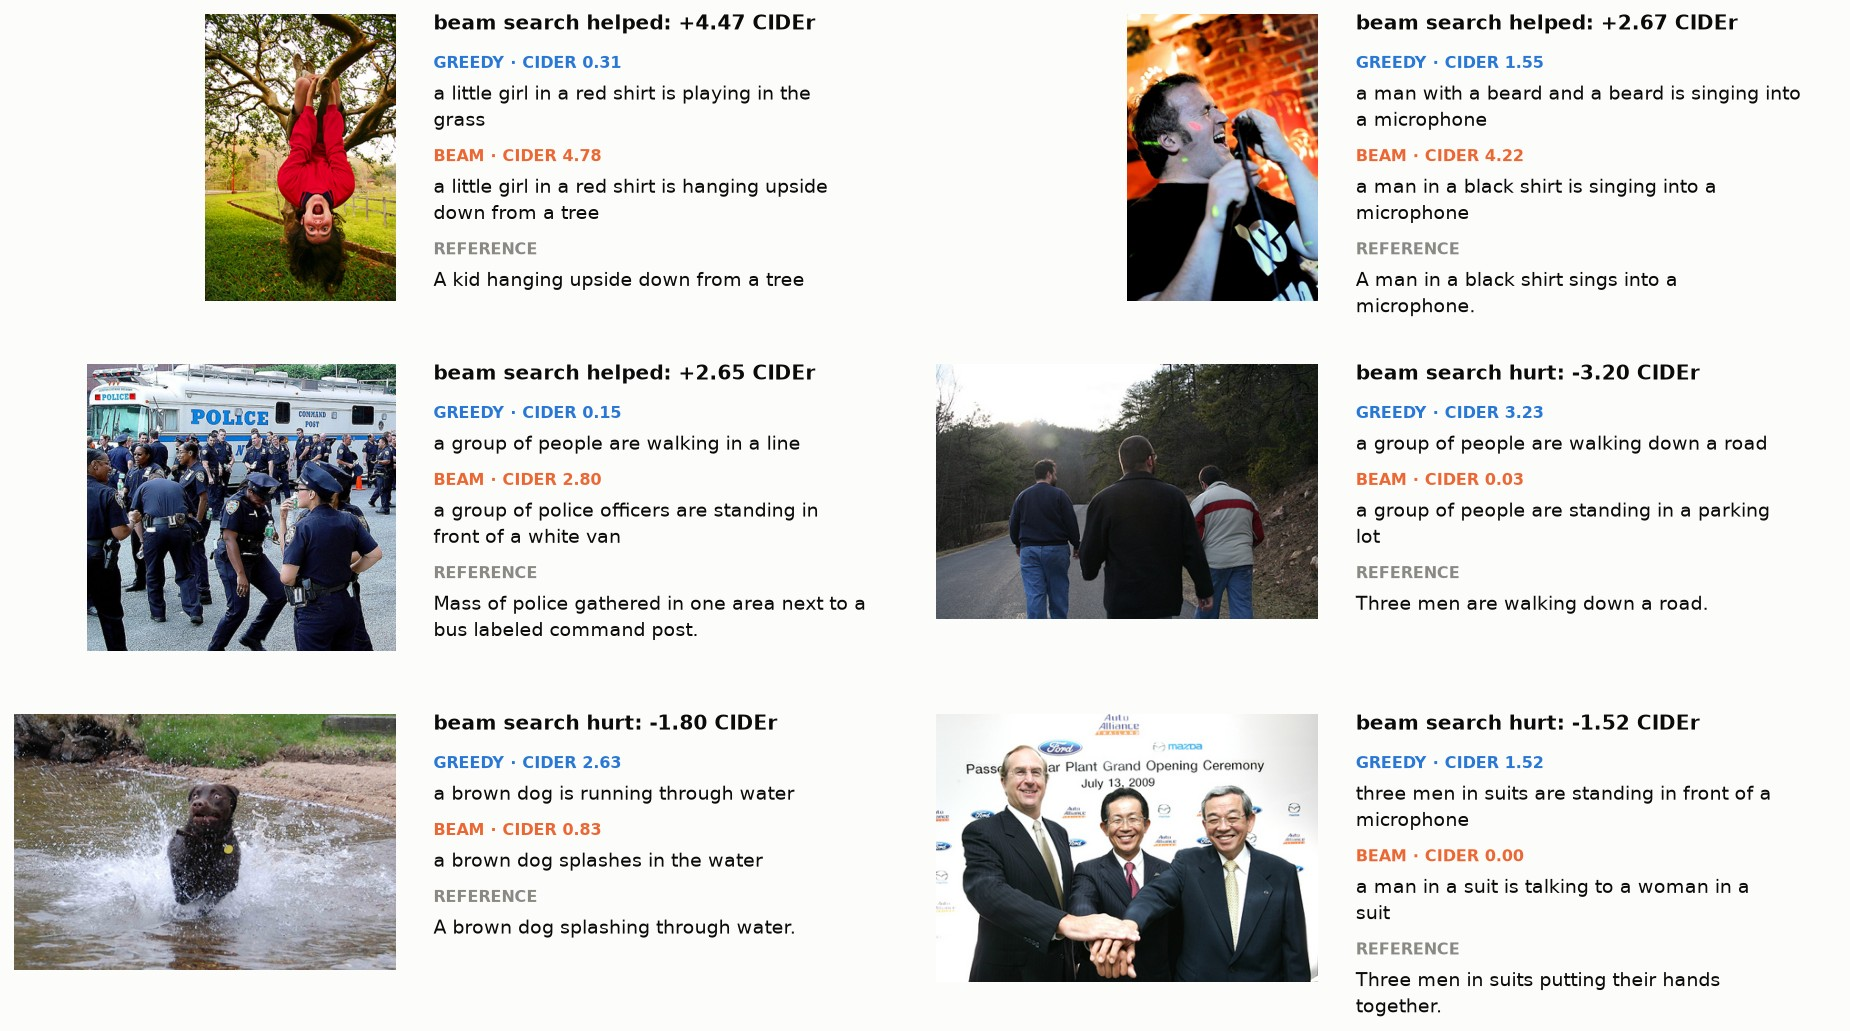

In [7]:
def per_image_cider(caps):
    ids = list(val_refs)
    _, s = Cider().compute_score({i: val_refs[i] for i in ids}, {i: [caps[i]] for i in ids})
    return dict(zip(ids, s))


g_scores, b_scores = per_image_cider(greedy), per_image_cider(beam)
order = sorted(val_refs, key=lambda f: b_scores[f] - g_scores[f])
by_name = {img["filename"]: img for img in val_images}


def example(f):
    gain = b_scores[f] - g_scores[f]
    return {"filename": f, "title": f"beam search {'helped' if gain > 0 else 'hurt'}: {gain:+.2f} CIDEr", "captions": [
        (f"greedy · CIDEr {g_scores[f]:.2f}", greedy[f]), (f"beam · CIDEr {b_scores[f]:.2f}", beam[f]),
        ("reference", rng.choice(by_name[f]["captions"]))]}


examples = [example(f) for f in order[-3:][::-1] + order[:3]]
colors = {ex["captions"][0][0]: viz.SERIES[0] for ex in examples} | {ex["captions"][1][0]: viz.SERIES[1] for ex in examples} | {"reference": viz.INK_3}
viz.show_captions(examples, IMAGE_DIR, colors=colors)

## 5. What the decoder looks at
Cross-attention over the 7×7 grid as each word is generated, averaged over layers and heads. Bright = attended. Averaging 24 heads blurs the maps; the LSTM's single attention (notebook 05) reads more clearly.

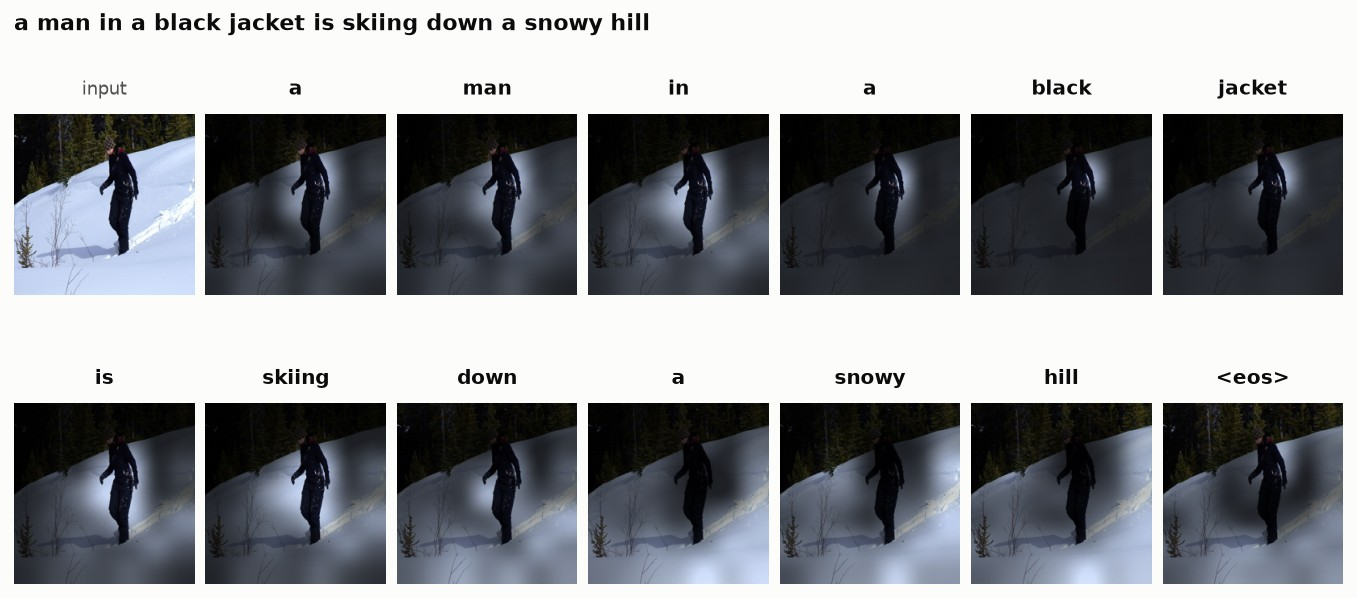

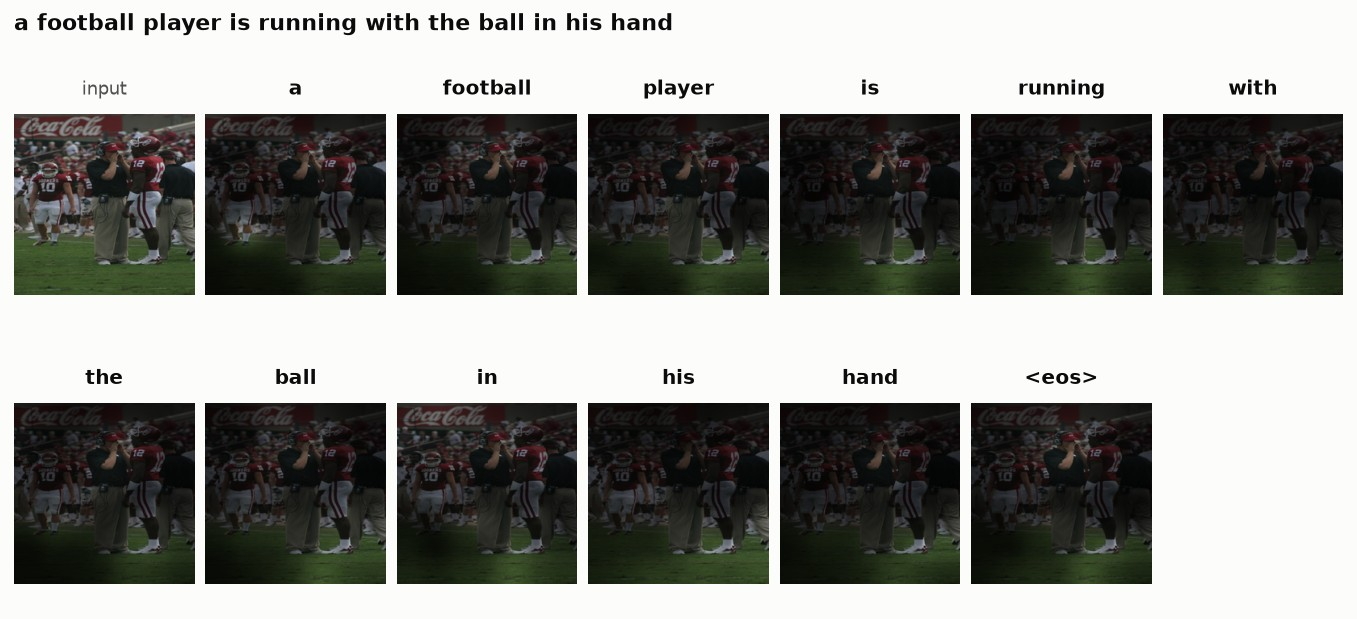

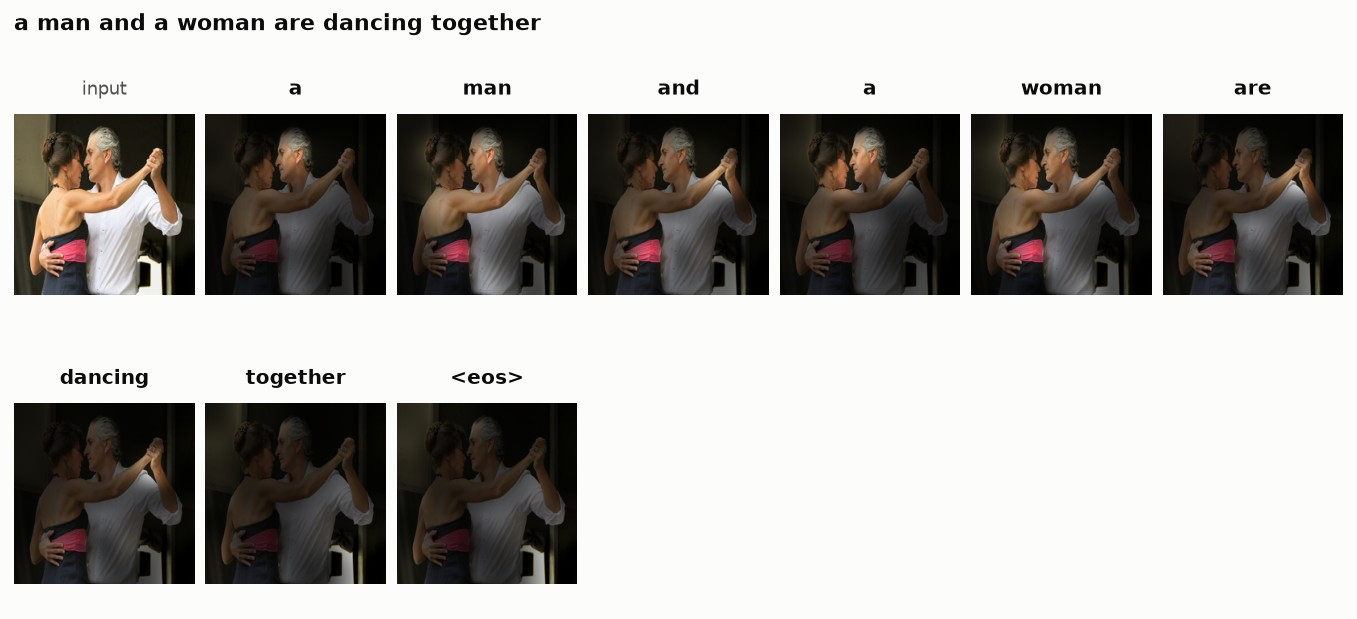

In [8]:
for img in np.random.default_rng(3).choice(val_images, 3, replace=False):
    feat = torch.from_numpy(np.array(features[img["feat_idx"]]))[None].to(device).float()
    ids = beam_search(model, feat, beam_size=BEST["beam_size"], length_penalty=BEST["length_penalty"])[0]
    with torch.no_grad():
        attn = model.attention_maps(feat, torch.tensor([[SOS_IDX] + ids], device=device))[0].float().cpu().numpy()
    words = [vocab.itos[i] for i in ids] + ["<eos>"]
    viz.show_attention(IMAGE_DIR / img["filename"], words, attn, title=" ".join(words[:-1]))

## Summary

- Greedy reproduces the checkpoint's val CIDEr exactly (0.476).
- **Best setting: k=10, α=1 → val CIDEr 0.509 (+6.9%)**; k=7 scores the same for a third of the time.
- **The length penalty decides whether wider beams help.** At α=0 they shorten captions to 8.5 words and CIDEr falls to 0.452; at α=1 length holds near 11 words and CIDEr keeps rising.
- Beam captions are slightly longer and less often copied from training, but repeat a phrase a bit more (9.5% vs 7.5%).